In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("AmesHousing.csv")

df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [3]:
df.isnull().sum().sort_values(ascending=False)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
                  ... 
Mo Sold              0
Yr Sold              0
Sale Type            0
Sale Condition       0
SalePrice            0
Length: 82, dtype: int64

In [4]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


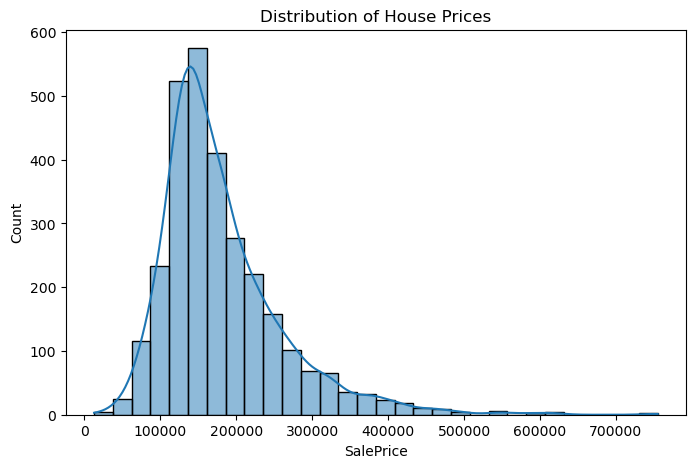

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice"], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.show()

LotArea
OverallQual
OverallCond
YearBuilt
GrLivArea
BedroomAbvGr
FullBath
GarageCars
Neighborhood

Larger area, better quality, newer construction, more bathrooms, garage capacity and premium neighborhoods generally increase property value.

In [6]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [7]:
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].fillna("Missing")

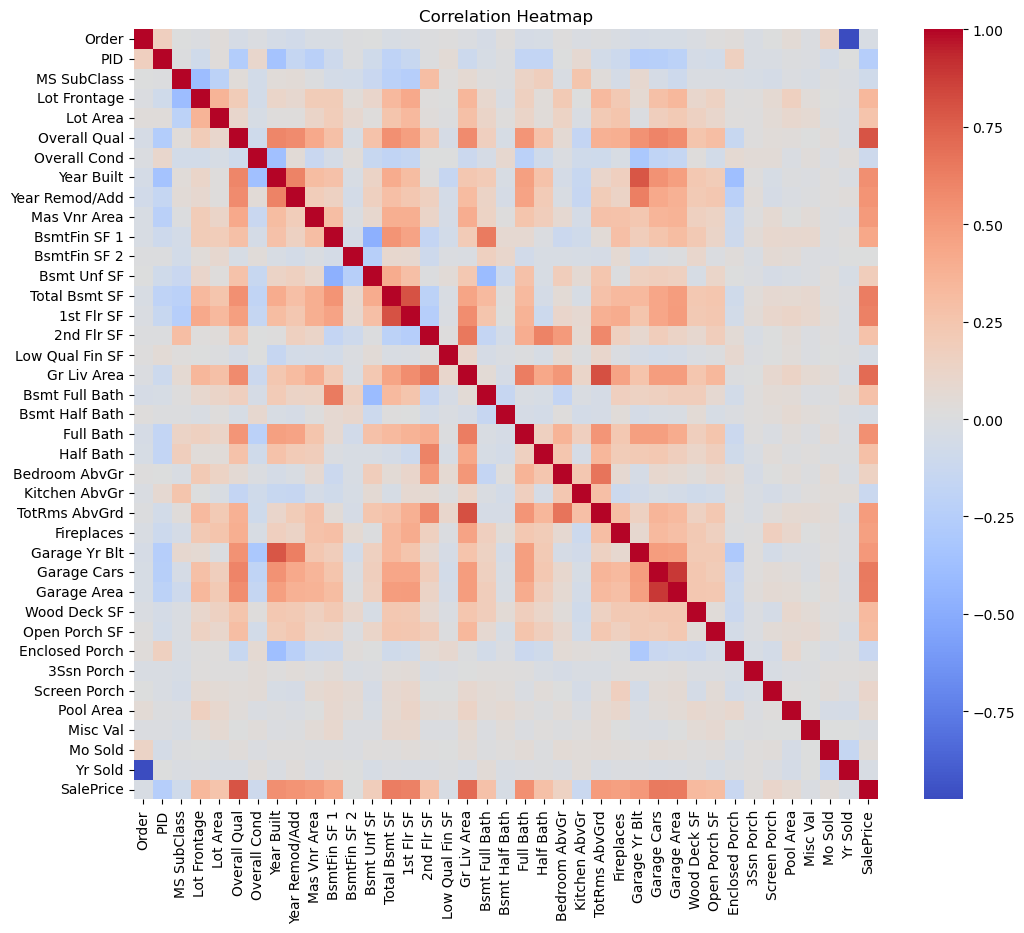

In [13]:
plt.figure(figsize=(12,10))

corr = df[numeric_cols].corr()

sns.heatmap(corr,cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [27]:
corr["SalePrice"].sort_values(ascending=False).head(15)

SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647812
Garage Area       0.640381
Total Bsmt SF     0.632164
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.508882
Mas Vnr Area      0.502196
TotRms AbvGrd     0.495474
Fireplaces        0.474558
BsmtFin SF 1      0.432862
Name: SalePrice, dtype: float64

In [14]:
X = df.drop("SalePrice", axis=1)

y = df["SalePrice"]

In [15]:
categorical = X.select_dtypes(include=['object']).columns
numeric = X.select_dtypes(exclude=['object']).columns

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown='ignore'), categorical),
    ("num", "passthrough", numeric)
])

In [16]:
X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [19]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour',
       'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Ex...
       'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd',
       'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area',
       'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch',
       'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold'],
      dtype='object'))])),
                ('regressor', LinearRegression())])

In [20]:
y_pred = model.predict(X_test)

In [21]:
mse = mean_squared_error(y_test,y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test,y_pred)

print("MSE :",mse)
print("RMSE :",rmse)
print("R2 Score :",r2)

MSE : 2112274136.2925968
RMSE : 45959.48363822854
R2 Score : 0.7365436222526653


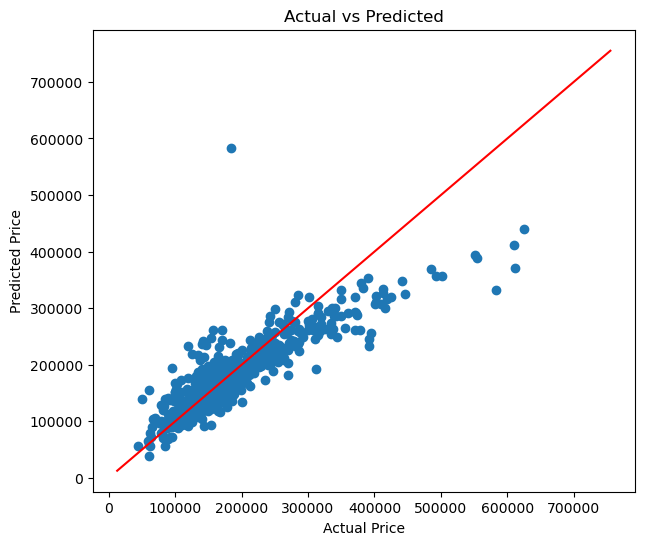

In [22]:
plt.figure(figsize=(7,6))

plt.scatter(y_test,y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.plot([y.min(),y.max()],
         [y.min(),y.max()],
         color="red")

plt.show()

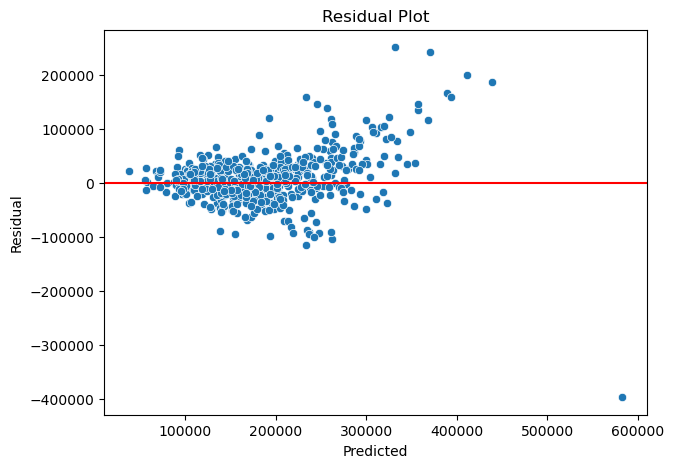

In [23]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))

sns.scatterplot(x=y_pred,y=residuals)

plt.axhline(0,color='red')

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [29]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

coefficients = model.named_steps["regressor"].coef_

coef_df = pd.DataFrame({
    "Feature":feature_names,
    "Coefficient":coefficients
})

coef_df.head()

,Feature,Coefficient
0,cat__MS Zoning_A (agr),-0.000277
1,cat__MS Zoning_C (all),-0.001530
2,cat__MS Zoning_FV,0.002955
3,cat__MS Zoning_I (all),-0.000126
4,cat__MS Zoning_RH,-0.000753


In [30]:
coef_df.sort_values(
    by="Coefficient",
    ascending=False
).head(10)

,Feature,Coefficient
296,num__Gr Liv Area,52.813924
292,num__Total Bsmt SF,37.793979
293,num__1st Flr SF,32.638037
289,num__BsmtFin SF 1,27.320235
294,num__2nd Flr SF,20.245886
307,num__Garage Area,19.414870
288,num__Mas Vnr Area,11.857747
291,num__Bsmt Unf SF,10.517829
308,num__Wood Deck SF,6.030017
309,num__Open Porch SF,3.066647


In [31]:
coef_df.sort_values(
    by="Coefficient"
).head(10)

,Feature,Coefficient
314,num__Misc Val,-4.404531
310,num__Enclosed Porch,-1.130707
281,num__MS SubClass,-0.107440
295,num__Low Qual Fin SF,-0.069999
143,cat__Exter Qual_TA,-0.045034
207,cat__Kitchen Qual_TA,-0.041852
160,cat__Bsmt Qual_TA,-0.035701
219,cat__Fireplace Qu_Missing,-0.033807
290,num__BsmtFin SF 2,-0.033686
150,cat__Foundation_CBlock,-0.032045


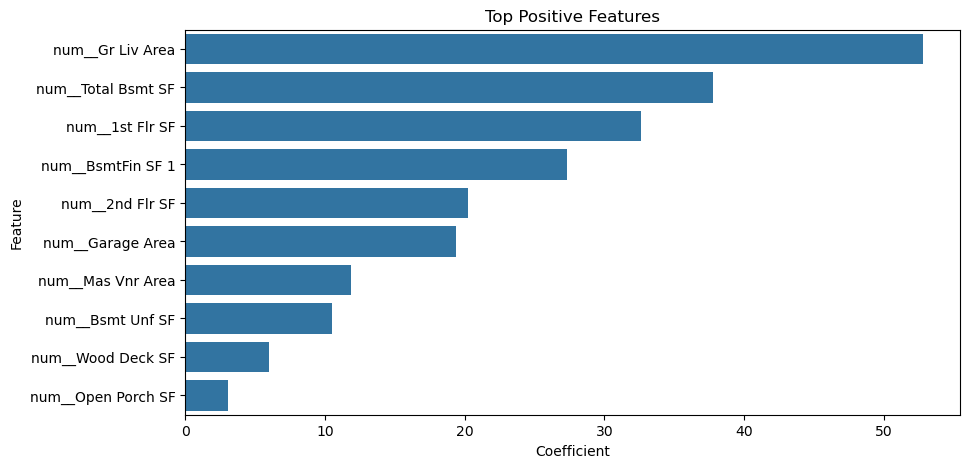

In [32]:
top = coef_df.sort_values(
    by="Coefficient",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Positive Features")

plt.show()

In [33]:
ridge = Pipeline([
    ("preprocessor",preprocessor),
    ("regressor",Ridge(alpha=1.0))
])

ridge.fit(X_train,y_train)

ridge_pred = ridge.predict(X_test)

ridge_rmse = np.sqrt(
    mean_squared_error(y_test,ridge_pred)
)

ridge_r2 = r2_score(
    y_test,
    ridge_pred
)

print("Ridge RMSE:",ridge_rmse)

print("Ridge R²:",ridge_r2)

Ridge RMSE: 86672.06442836706
Ridge R²: 0.06304934912631288


In [34]:
comparison = pd.DataFrame({
    "Model":["Linear Regression","Ridge Regression"],
    "RMSE":[rmse,ridge_rmse],
    "R² Score":[r2,ridge_r2]
})

comparison

,Model,RMSE,R² Score
0,Linear Regression,45959.483638,0.736544
1,Ridge Regression,86672.064428,0.063049
